# Hướng dẫn Analysis Bot & Signal Visualization

Tutorial này bao gồm:

1. **Query dữ liệu** OHLCV cho SHB, VHM từ đầu năm 2026
2. **Sử dụng strategies** (RSI, MACD, SMA) với `attach_snapshot=True`
3. **Batch analysis** – quét tín hiệu trên toàn bộ DataFrame
4. **Backtest với AnalysisBot** – chạy bot qua engine
5. **Visualization** – plot biểu đồ nến + indicator + Entry/SL/TP
6. **SignalStore** – lưu & query signals đã accept

## 1. Query dữ liệu OHLCV

Sử dụng `query_ohlcv_grouped()` để lấy dữ liệu daily cho **SHB** và **VHM** từ Q4-2025 (cần lookback cho indicator) đến hiện tại.

In [12]:
import pandas as pd
from vnstock_forecast.engine.data.query import query_ohlcv_grouped, query_ohlcv

# Lấy dữ liệu từ 2025-10-01 để có đủ lookback cho MACD (slow=26 + signal=9)
from_ts = int(pd.Timestamp("2025-01-01").timestamp())
grouped = query_ohlcv_grouped(
    symbols=["SHB", "VHM"],
    resolutions="D",
    lookback_bars=200
)

# Truy cập: grouped[resolution][symbol] → DataFrame OHLCV
df_shb = grouped["D"]["SHB"]
df_vhm = grouped["D"]["VHM"]

print(f"SHB: {df_shb.shape[0]} bars,  {df_shb.index[0]}  →  {df_shb.index[-1]}")
print(f"VHM: {df_vhm.shape[0]} bars,  {df_vhm.index[0]}  →  {df_vhm.index[-1]}")
df_shb

SHB: 200 bars,  1748563200  →  1773792000
VHM: 200 bars,  1748563200  →  1773792000


,Open,High,Low,Close,Volume
Timestamp,,,,,
1748563200,11595.31920,11680.57890,11339.54010,11552.68935,87199800.0
1748822400,11424.79980,11680.57890,11382.16995,11680.57890,56189900.0
1748908800,11680.57890,11978.98785,11595.31920,11851.09830,95228600.0
1748995200,11851.09830,12021.61770,11765.83860,11765.83860,53770800.0
1749081600,11723.20875,11765.83860,11637.94905,11680.57890,33522900.0
...,...,...,...,...,...
1773273600,14600.00000,15100.00000,14450.00000,14950.00000,83295200.0
1773360000,14650.00000,14950.00000,14600.00000,14950.00000,57514000.0
1773619200,14850.00000,15300.00000,14700.00000,15200.00000,84195400.0


## 2. Batch Analysis – quét tín hiệu với từng Strategy

Mỗi strategy (RSICrossover, MACDCrossover, SMACrossover) có thể chạy độc lập qua `analyze_batch()`.

Bật `attach_snapshot = True` để mỗi signal mang theo đủ dữ liệu OHLCV + indicator overlays dùng cho visualization.

In [13]:
from vnstock_forecast.builtin.signal_based.registry import get_technique, list_technique_names
print("Available techniques:")
for name in list_technique_names():
    print(f"  - {name}")
    print(f"    {get_technique(name)}")

Available techniques:
  - macd_crossover
    <class 'user.builtin.bots.technical.strategies.macd_crossover.MACDCrossover'>
  - rsi_crossover
    <class 'user.builtin.bots.technical.strategies.rsi_crossover.RSICrossover'>
  - sma_crossover
    <class 'user.builtin.bots.technical.strategies.sma_crossover.SMACrossover'>
  - sma_short_crossover
    <class 'user.builtin.bots.technical.strategies.sma_short_crossover.SMAShortCrossover'>


In [14]:

from vnstock_forecast.builtin.signal_based.registry import (
    get_technique
)

# ---- Tạo bot kết hợp RSI + MACD ----
# rsi_tech = RSICrossover(period=14)
# rsi_tech.attach_snapshot = True

from vnstock_forecast.builtin.signal_based.signal import SignalDirection

# ---- Khởi tạo strategies, bật snapshot ----
MACDCrossover = get_technique("sma_short_crossover")
macd = MACDCrossover()
macd.attach_snapshot = True

RSICrossover = get_technique("rsi_crossover")
rsi = RSICrossover()
rsi.attach_snapshot = True
SMACrossover = get_technique("sma_short_crossover")
sma = SMACrossover()
sma.attach_snapshot = True
SMAShortCrossover = get_technique("sma_short_crossover")
sma_short = SMAShortCrossover()
sma_short.attach_snapshot = True

# ---- Quét tín hiệu trên SHB ----
# rsi_signals = rsi.analyze_batch(df_shb, "SHB")
# macd_signals = macd.analyze_batch(df_shb, "SHB")
# sma_signals = sma.analyze_batch(df_shb, "SHB")
sma_short_signals = sma_short.analyze_batch(df_shb, "SHB")
sma_short_signals += sma_short.analyze_batch(df_vhm, "VHM")

# all_signals = rsi_signals + macd_signals + sma_signals  + sma_short_signals
all_signals = sma_short_signals
buys = [s for s in all_signals if s.direction == SignalDirection.BUY]
sells = [s for s in all_signals if s.direction == SignalDirection.SELL]

# print(f"RSI  → {len(rsi_signals)} signals")
# print(f"MACD → {len(macd_signals)} signals")
# print(f"SMA  → {len(sma_signals)} signals")
print(f"SMA Short  → {len(sma_short_signals)} signals")
print(f"\nTổng: {len(all_signals)} signals ({len(buys)} BUY, {len(sells)} SELL)")

# Xem nhanh
for s in all_signals:
    direction = "🟢 BUY " if s.is_buy else "🔴 SELL"
    snap_ok = "✓ snap" if s.snapshot else "✗"
    entry_info = f"entry={s.trade_plan.entry:,.0f}" if s.trade_plan else ""
    print(f"  {direction} [{s.technique:16s}] {s.timestamp.date()} {entry_info:>14s}  conf={s.confidence:.2f}  {snap_ok}")

SMA Short  → 14 signals

Tổng: 14 signals (6 BUY, 8 SELL)
  🔴 SELL [sma_short_crossover] 2025-09-19                 conf=0.50  ✓ snap
  🟢 BUY  [sma_short_crossover] 2025-10-15   entry=18,200  conf=0.51  ✓ snap
  🔴 SELL [sma_short_crossover] 2025-10-24                 conf=0.50  ✓ snap
  🟢 BUY  [sma_short_crossover] 2025-11-26   entry=16,700  conf=0.51  ✓ snap
  🔴 SELL [sma_short_crossover] 2025-12-17                 conf=0.50  ✓ snap
  🟢 BUY  [sma_short_crossover] 2026-01-14   entry=16,700  conf=0.51  ✓ snap
  🔴 SELL [sma_short_crossover] 2026-01-28                 conf=0.50  ✓ snap
  🔴 SELL [sma_short_crossover] 2025-09-29                 conf=0.50  ✓ snap
  🟢 BUY  [sma_short_crossover] 2025-10-09  entry=115,000  conf=0.80  ✓ snap
  🔴 SELL [sma_short_crossover] 2025-10-31                 conf=0.50  ✓ snap
  🟢 BUY  [sma_short_crossover] 2025-12-01  entry=105,700  conf=0.52  ✓ snap
  🔴 SELL [sma_short_crossover] 2025-12-22                 conf=0.50  ✓ snap
  🟢 BUY  [sma_short_crossover]

## 3. Visualization – Plot Signal trên biểu đồ nến

`plot_signal()` nhận trực tiếp `Signal` (có snapshot) hoặc `SignalSnapshot`, render biểu đồ nến gồm:
- **Entry** (xanh dương), **SL** (đỏ), **TP** (xanh lá) tại đúng mức giá
- Vùng tô risk (đỏ nhạt) / reward (xanh nhạt)
- Indicator subplot (RSI, MACD, …)
- Mũi tên đánh dấu thời điểm phát signal

RSI BUY @ 2025-10-15 — SMA(10)=17585 cắt lên SMA(30)=17577 | gap=0.05% slope=0.716%
  Entry: 18,200  SL: 17,593  TP: 20,020
  R:R = 1:3.00


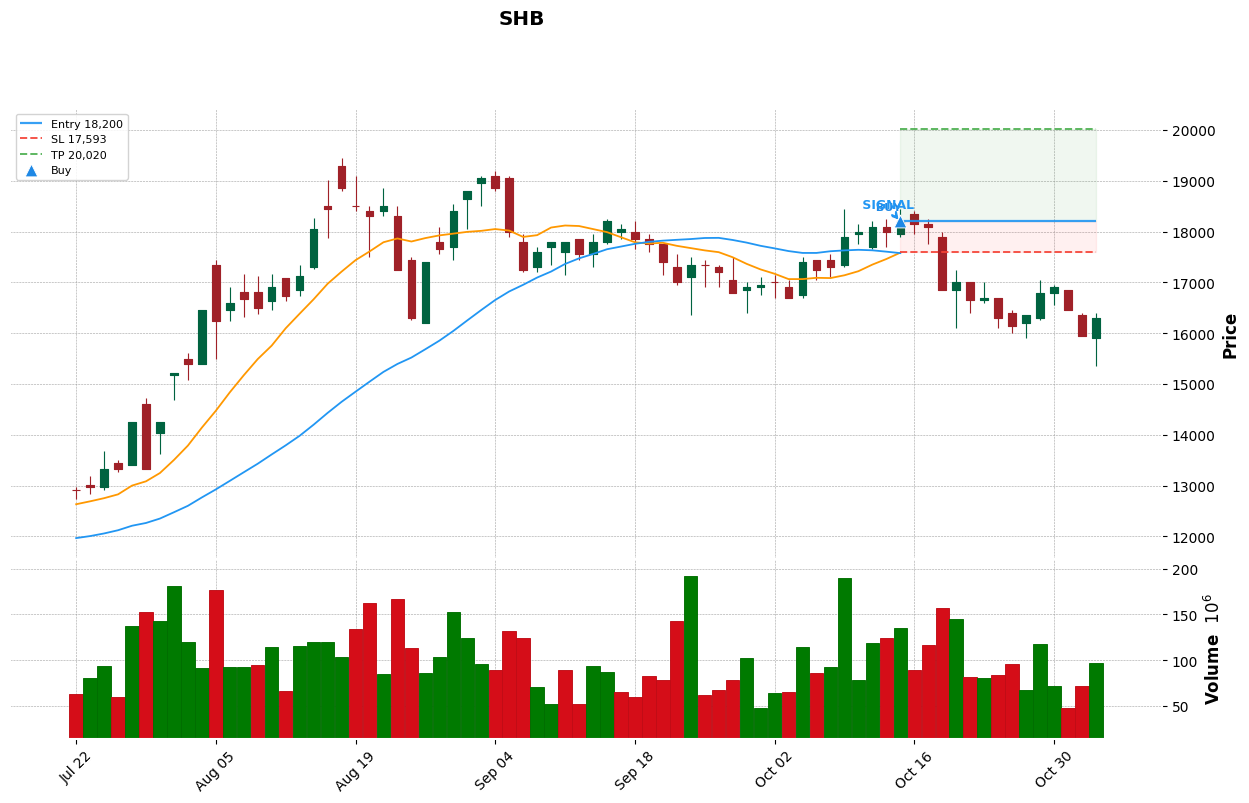

In [15]:
%matplotlib inline
from vnstock_forecast.builtin.signal_based.visualization import plot_signal

# ---- Plot signal BUY đầu tiên (RSI) ----
all_signals = [s for s in all_signals if s.is_buy and s.snapshot]
if all_signals:
    sig = all_signals[0]
    # print(sig.snapshot)
    print(f"RSI BUY @ {sig.timestamp.date()} — {sig.reason}")
    print(f"  Entry: {sig.trade_plan.entry:,.0f}  SL: {sig.trade_plan.stop_loss:,.0f}  TP: {sig.trade_plan.take_profit:,.0f}")
    print(f"  R:R = 1:{sig.trade_plan.rr_ratio():.2f}")
    plot_signal(sig, extend_bars=20, show=True, figsize=(16, 9))
else:
    print("Không có RSI BUY signal nào cho SHB trong khoảng dữ liệu này.")

## 4. Backtest với AnalysisBot

`AnalysisBot` tổ hợp nhiều technique, chạy qua `BacktestEngine` bar-by-bar.  
Bật `attach_snapshot = True` trên mỗi technique để signals trong `bot.signal_history` đều có snapshot sẵn sàng plot.

In [ ]:
from vnstock_forecast.builtin.signal_based.technical.backtest import SignalBasedBacktestBot
from vnstock_forecast.engine.backtest.backtest import BacktestEngine
# from user.builtin.bots.technical.strategies import RSICrossover, MACDCrossover, SMACrossover
from vnstock_forecast.builtin.signal_based.registry import (
    get_technique
)
MACDCrossover = get_technique("sma_short_crossover")

# ---- Tạo bot kết hợp RSI + MACD ----
# rsi_tech = RSICrossover(period=14)
# rsi_tech.attach_snapshot = True

macd_tech = MACDCrossover()
macd_tech.attach_snapshot = True

bot = SignalBasedBacktestBot(
    name="sma_tech",
    techniques=[macd_tech],
    allocation=0.3,         # 30% vốn mỗi lệnh mua
    # emit_sl_tp_signals=True,
)

# ---- Chạy backtest – dùng cả SHB + VHM ----
data = grouped["D"]  # {"SHB": df, "VHM": df}

engine = BacktestEngine(
    initial_cash=100000000,  # 500 triệu VND
    commission_rate=0.0015,
    settlement_days=2,
    # auto_manage_sl_tp=False
)

report = engine.run(bot, data, start="2025-06-01")
report.print_summary()

  BACKTEST REPORT: sma_tech
  Symbols:        SHB, VHM
  Period:         2025-06-02 → 2026-03-18
  Commission:     0.15%
------------------------------------------------------------
  Initial Cash:       100,000,000
  Final Equity:       103,908,692
  Total PnL:            4,289,620
  Total Return:             3.91%
------------------------------------------------------------
  Trades:                       7
  Wins:                         3
  Losses:                       4
  Win Rate:                 42.9%
  Avg Win:                 10.00%
  Avg Loss:                -3.33%
  R:R Ratio:                 3.00
  Max Drawdown:             2.35%
------------------------------------------------------------
  Close Reasons:  {'take_profit': 3, 'stop_loss': 4}


In [8]:
report.trade_history()

,id,symbol,entry_time,exit_time,entry_price,exit_price,quantity,stop_loss,take_profit,pnl,pnl_pct,close_reason
0,baef244c,SHB,2025-07-08,2025-07-28,12521.2218,13773.34,1718,11552.69,13773.34,2151139.0,10.00,take_profit
1,21f70e7d,VHM,2025-10-09,2025-10-14,115000.0000,126500.00,213,102700.00,126500.00,2449500.0,10.00,take_profit
2,dc777710,SHB,2025-10-15,2025-10-20,18200.0000,17593.33,882,17593.33,20020.00,-535083.0,-3.33,stop_loss
3,23f9802a,SHB,2025-11-26,2025-12-09,16700.0000,16143.33,946,16143.33,18370.00,-526610.0,-3.33,stop_loss
4,b839a212,VHM,2025-12-01,2025-12-10,105700.0000,102176.67,129,102176.67,116270.00,-454510.0,-3.33,stop_loss
5,6b5b90a8,VHM,2025-12-25,2026-01-05,114300.0000,125730.00,152,108000.00,125730.00,1737360.0,10.00,take_profit
6,c2547c9b,SHB,2026-01-14,2026-01-26,16700.0000,16143.33,956,16143.33,18370.00,-532177.0,-3.33,stop_loss


In [9]:
# ---- Xem signal_history từ backtest ----
print(f"Bot đã ghi nhận {len(bot.signal_history)} signals trong quá trình backtest:\n")

for s in bot.signal_history:
    d = "🟢 BUY " if s.is_buy else "🔴 SELL"
    snap = "✓ snap" if s.snapshot else ""
    entry = f"entry={s.trade_plan.entry:,.0f}" if s.trade_plan else ""
    print(f"  {d} {s.symbol:4s} [{s.technique:16s}] {s.timestamp.date()}  {entry:>14s}  {snap}")

Bot đã ghi nhận 7 signals trong quá trình backtest:

  🟢 BUY  SHB  [sma_short_crossover] 2025-07-08    entry=12,521  ✓ snap
  🟢 BUY  VHM  [sma_short_crossover] 2025-10-09   entry=115,000  ✓ snap
  🟢 BUY  SHB  [sma_short_crossover] 2025-10-15    entry=18,200  ✓ snap
  🟢 BUY  SHB  [sma_short_crossover] 2025-11-26    entry=16,700  ✓ snap
  🟢 BUY  VHM  [sma_short_crossover] 2025-12-01   entry=105,700  ✓ snap
  🟢 BUY  VHM  [sma_short_crossover] 2025-12-25   entry=114,300  ✓ snap
  🟢 BUY  SHB  [sma_short_crossover] 2026-01-14    entry=16,700  ✓ snap


SignalSnapshot(ohlcv=                Open      High       Low     Close      Volume
Timestamp                                                     
2025-10-03   98600.0  100000.0   96000.0  100000.0   4683200.0
2025-10-06  103900.0  103900.0  100500.0  102700.0   5972800.0
2025-10-07  103000.0  104600.0  102200.0  103100.0   6428600.0
2025-10-08  103500.0  107500.0  101200.0  107500.0   8989300.0
2025-10-09  108300.0  115000.0  108100.0  115000.0  12892200.0
2025-10-10  118000.0  123000.0  116000.0  123000.0   9026200.0
2025-10-13  123000.0  126000.0  122100.0  124200.0  12312200.0
2025-10-14  124500.0  131500.0  124500.0  127000.0  13660200.0
2025-10-15  127500.0  127600.0  122600.0  124000.0   7059300.0
2025-10-16  123800.0  123800.0  120400.0  122000.0   9475900.0
2025-10-17  122000.0  122000.0  114600.0  116000.0  12213500.0
2025-10-20  114000.0  115000.0  108000.0  108000.0  11634800.0
2025-10-21  109000.0  115000.0  106900.0  110900.0   8238300.0
2025-10-22  112000.0  113000.0  10

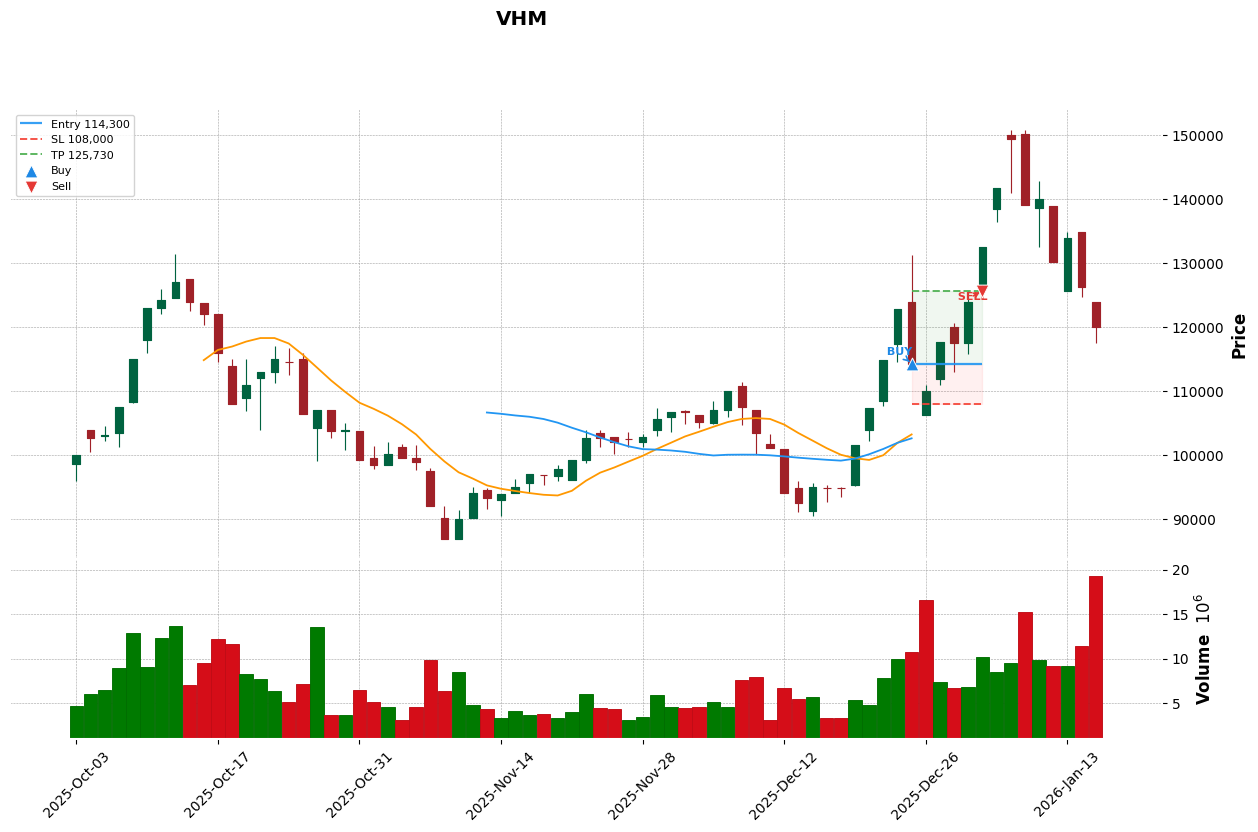

In [10]:
# ---- Plot BUY signal đầu tiên từ backtest history ----
from vnstock_forecast.builtin.signal_based.visualization import plot_signal
import random
bt_buys = [s for s in bot.signal_history if s.is_buy and s.snapshot]
if bt_buys:
    sig = bt_buys[random.randint(0, len(bt_buys)-1)]
    print(sig.snapshot)
    # print(sig.snapshot)
    print(f"[Backtest] {sig.technique} BUY {sig.symbol} @ {sig.timestamp.date()}")
    print(f"  Entry: {sig.trade_plan.entry:,.0f}  SL: {sig.trade_plan.stop_loss:,.0f}  TP: {sig.trade_plan.take_profit:,.0f}")
    plot_signal(sig, extend_bars=10, figsize=(16, 9))
else:
    print("Không có BUY signal với snapshot trong backtest.")

## 5. Equity Curve & Trade History

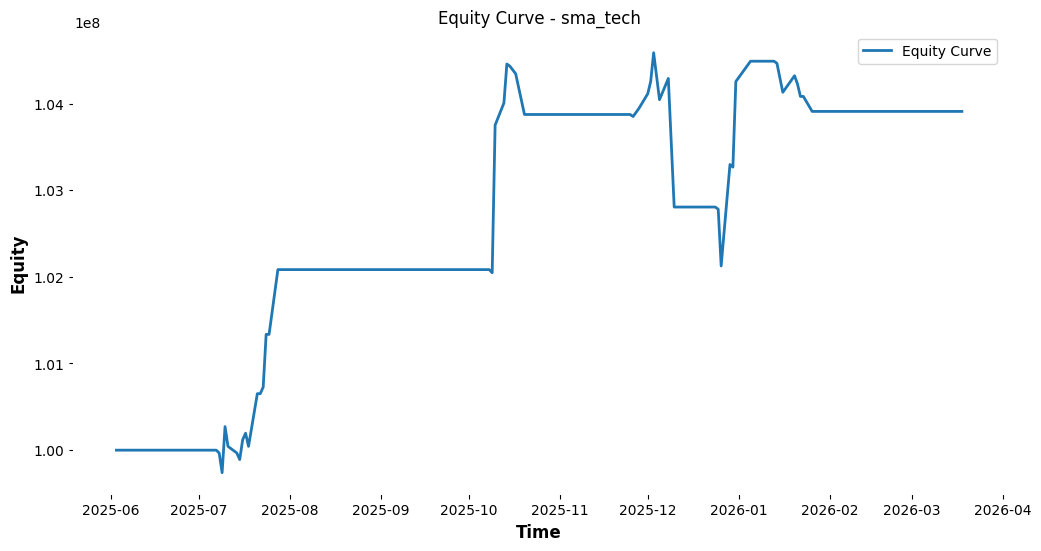

,id,symbol,entry_time,exit_time,entry_price,exit_price,quantity,stop_loss,take_profit,pnl,pnl_pct,close_reason
0,baef244c,SHB,2025-07-08,2025-07-28,12521.2218,13773.34,1718,11552.69,13773.34,2151139.0,10.00,take_profit
1,21f70e7d,VHM,2025-10-09,2025-10-14,115000.0000,126500.00,213,102700.00,126500.00,2449500.0,10.00,take_profit
2,dc777710,SHB,2025-10-15,2025-10-20,18200.0000,17593.33,882,17593.33,20020.00,-535083.0,-3.33,stop_loss
3,23f9802a,SHB,2025-11-26,2025-12-09,16700.0000,16143.33,946,16143.33,18370.00,-526610.0,-3.33,stop_loss
4,b839a212,VHM,2025-12-01,2025-12-10,105700.0000,102176.67,129,102176.67,116270.00,-454510.0,-3.33,stop_loss
5,6b5b90a8,VHM,2025-12-25,2026-01-05,114300.0000,125730.00,152,108000.00,125730.00,1737360.0,10.00,take_profit
6,c2547c9b,SHB,2026-01-14,2026-01-26,16700.0000,16143.33,956,16143.33,18370.00,-532177.0,-3.33,stop_loss


In [11]:
# Equity curve
report.plot_equity()

# Trade history table
report.trade_history()

In [12]:
report.event_log()

,timestamp,action,symbol,price,quantity,position_id,equity,reason
0,2025-07-08,buy,SHB,12521.2218,1718,baef244c,9.996773e+07,[sma_short_crossover] SMA(10)=11667 cắt lên SM...
1,2025-07-28,take_profit,SHB,13773.3400,1718,baef244c,1.020834e+08,Auto take_profit
2,2025-10-09,buy,VHM,115000.0000,213,21f70e7d,1.020466e+08,[sma_short_crossover] SMA(10)=103200 cắt lên S...
3,2025-10-14,take_profit,VHM,126500.0000,213,21f70e7d,1.044557e+08,Auto take_profit
4,2025-10-15,buy,SHB,18200.0000,882,dc777710,1.044316e+08,[sma_short_crossover] SMA(10)=17585 cắt lên SM...
5,2025-10-20,stop_loss,SHB,17593.3300,882,dc777710,1.038733e+08,Auto stop_loss
6,2025-11-26,buy,SHB,16700.0000,946,23f9802a,1.038496e+08,[sma_short_crossover] SMA(10)=16520 cắt lên SM...
7,2025-12-01,buy,VHM,105700.0000,129,b839a212,1.041129e+08,[sma_short_crossover] SMA(10)=100950 cắt lên S...
8,2025-12-09,stop_loss,SHB,16143.3300,946,23f9802a,1.035118e+08,Auto stop_loss
9,2025-12-10,stop_loss,VHM,102176.6700,129,b839a212,1.028053e+08,Auto stop_loss


## 6. SignalStore – Lưu & Query Signals

`SignalStore` lưu mỗi signal ra file pickle, query theo technique / symbol / direction / time range.

In [13]:
import tempfile
from vnstock_forecast.builtin.signal_based.visualization import SignalStore

# Tạo store tạm (thực tế dùng đường dẫn cố định, ví dụ "outputs/signals")
store_dir = tempfile.mkdtemp(prefix="signal_store_")
store = SignalStore(store_dir)

# Lưu tất cả signals từ backtest
ids = store.save_many(bot.signal_history)
print(f"Đã lưu {len(ids)} signals vào {store_dir}")
for sid in ids:
    print(f"  • {sid}")

# ---- Query ----
# Tìm tất cả BUY signals cho SHB
shb_buys = store.query(symbol="SHB", direction=SignalDirection.BUY)
print(f"\nQuery SHB BUY → {len(shb_buys)} kết quả")

# Tìm signals theo technique
macd_sigs = store.query(technique="macd_crossover")
print(f"Query macd_crossover → {len(macd_sigs)} kết quả")

Đã lưu 7 signals vào /tmp/signal_store_ccecv3gd
  • sma_short_crossover__SHB__20250708_000000__19b2c53a
  • sma_short_crossover__VHM__20251009_000000__28f510da
  • sma_short_crossover__SHB__20251015_000000__a67eae7c
  • sma_short_crossover__SHB__20251126_000000__99ca6412
  • sma_short_crossover__VHM__20251201_000000__d1e76380
  • sma_short_crossover__VHM__20251225_000000__7221c014
  • sma_short_crossover__SHB__20260114_000000__31d1a909

Query SHB BUY → 4 kết quả
Query macd_crossover → 0 kết quả


Loaded: sma_short_crossover SHB @ 2025-07-08


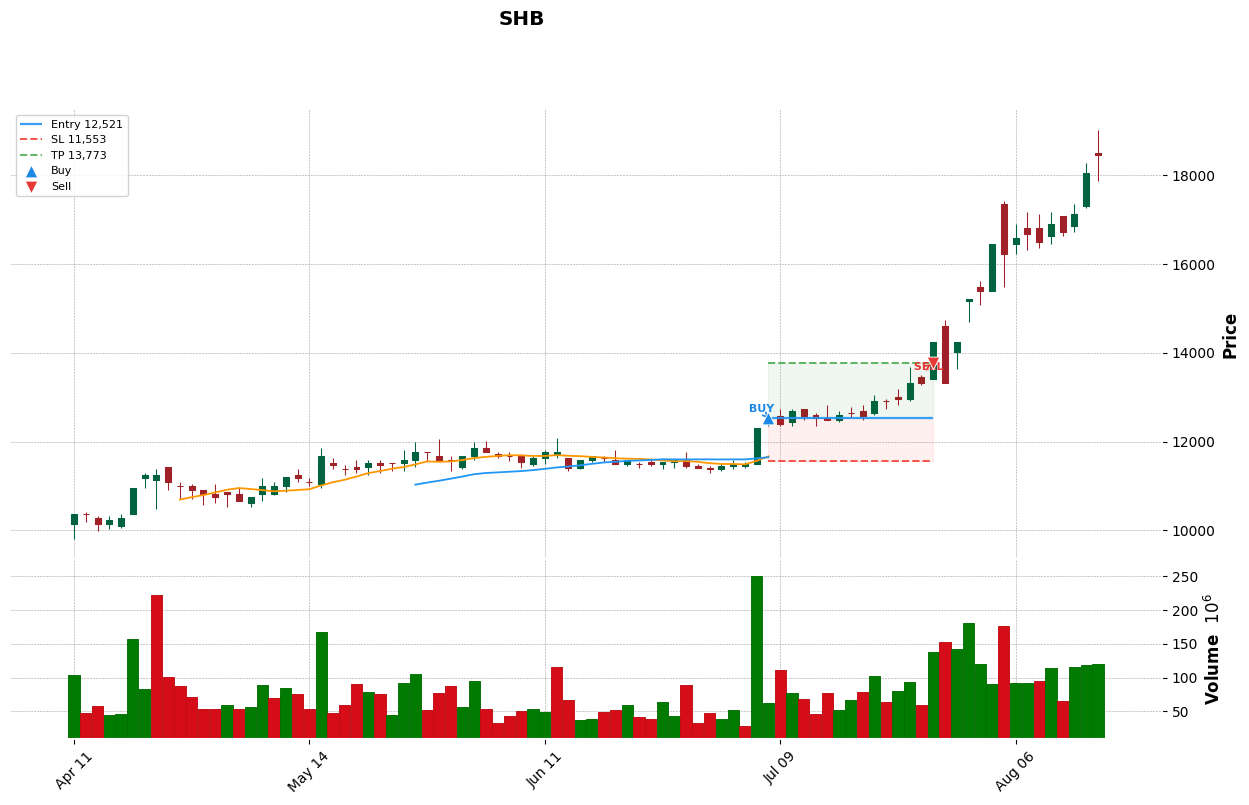

In [14]:
# ---- Load & plot từ store ----
if shb_buys:
    loaded = shb_buys[0]
    print(f"Loaded: {loaded.technique} {loaded.symbol} @ {loaded.timestamp.date()}")
    if loaded.snapshot:
        plot_signal(loaded, extend_bars=20, figsize=(16, 9))
    else:
        print("Signal không có snapshot.")